In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False
df = pd.read_csv(r'D:\JUPYTER NOTEBOOK\数据集\Global_Teen_MentalHealth_Habit_Data\modern_teen_mental_health_main.csv')

In [2]:
df

,student_id,date,age,gender,country,grade,mood,stress_level,sleep_hours,screen_time_hours,used_ai_today,ai_tool,journaled_today,meditated_today,exercised_today,social_interaction_rating,support_feeling
0,S0001,2025-01-01,15,Female,USA,11th,5,5,3.6,2.1,False,NaN,False,False,True,6,7
1,S0001,2025-01-02,15,Female,USA,11th,6,4,9.1,8.8,True,Phind,True,False,True,4,7
2,S0001,2025-01-03,15,Female,USA,11th,8,2,8.5,7.8,True,Notion AI,False,True,False,6,5
3,S0001,2025-01-04,15,Female,USA,11th,5,6,4.9,6.1,False,NaN,True,True,False,5,9
4,S0001,2025-01-05,15,Female,USA,11th,9,1,7.7,7.5,False,NaN,True,True,False,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,S1000,2025-01-26,14,Other,Australia,10th,3,7,8.9,6.3,True,Gemini,False,True,True,5,6
29996,S1000,2025-01-27,14,Other,Australia,10th,5,6,5.2,9.0,False,NaN,True,False,True,3,8
29997,S1000,2025-01-28,14,Other,Australia,10th,3,7,6.4,9.2,True,ChatGPT,True,True,False,8,9
29998,S1000,2025-01-29,14,Other,Australia,10th,5,5,7.4,4.7,False,NaN,False,False,False,3,9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 30000 non-null  str    
 1   date                       30000 non-null  str    
 2   age                        30000 non-null  int64  
 3   gender                     30000 non-null  str    
 4   country                    30000 non-null  str    
 5   grade                      30000 non-null  str    
 6   mood                       30000 non-null  int64  
 7   stress_level               30000 non-null  int64  
 8   sleep_hours                30000 non-null  float64
 9   screen_time_hours          30000 non-null  float64
 10  used_ai_today              30000 non-null  bool   
 11  ai_tool                    17991 non-null  str    
 12  journaled_today            30000 non-null  bool   
 13  meditated_today            30000 non-null  bool   
 14  e

In [4]:
df.describe()

,age,mood,stress_level,sleep_hours,screen_time_hours,social_interaction_rating,support_feeling
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000
mean,15.557000,6.000733,4.043867,6.487783,6.980977,6.01370,6.500267
std,1.123741,1.991866,2.069449,1.493795,1.993324,1.99786,1.713271
min,14.000000,3.000000,1.000000,0.200000,-0.800000,3.00000,4.000000
25%,15.000000,4.000000,2.000000,5.500000,5.600000,4.00000,5.000000
50%,16.000000,6.000000,4.000000,6.500000,7.000000,6.00000,6.000000
75%,17.000000,8.000000,6.000000,7.500000,8.300000,8.00000,8.000000
max,17.000000,9.000000,8.000000,12.300000,15.600000,9.00000,9.000000


In [5]:
df['ai_tool'] = df['ai_tool'].fillna('未使用AI')
df["date"] = pd.to_datetime(df["date"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   student_id                 30000 non-null  str           
 1   date                       30000 non-null  datetime64[us]
 2   age                        30000 non-null  int64         
 3   gender                     30000 non-null  str           
 4   country                    30000 non-null  str           
 5   grade                      30000 non-null  str           
 6   mood                       30000 non-null  int64         
 7   stress_level               30000 non-null  int64         
 8   sleep_hours                30000 non-null  float64       
 9   screen_time_hours          30000 non-null  float64       
 10  used_ai_today              30000 non-null  bool          
 11  ai_tool                    30000 non-null  str           
 12  journaled_today

In [7]:
all_err = df[(df['sleep_hours']<1)|(df['sleep_hours']>12)|(df['screen_time_hours']<0)|(df['screen_time_hours']>15)]
print("两类异常合计总行数：",len(all_err))

两类异常合计总行数： 14


In [8]:
df = df[(df['sleep_hours'] >= 1) & (df['sleep_hours'] <= 12)]
df = df[(df['screen_time_hours'] >= 0) & (df['screen_time_hours'] <= 15)]
df.describe()[['sleep_hours','screen_time_hours']]

,sleep_hours,screen_time_hours
count,29986.000000,29986.000000
mean,6.488281,6.982692
min,1.200000,-0.000000
25%,5.500000,5.600000
50%,6.500000,7.000000
75%,7.500000,8.300000
max,12.000000,14.900000
std,1.492481,1.989071


In [9]:
conflict = df[((df['used_ai_today']==True)&(df['ai_tool']=='未使用AI'))|((df['used_ai_today']==False)&(df['ai_tool']!='未使用AI'))]
print("AI字段逻辑冲突样本数量：", len(conflict))

AI字段逻辑冲突样本数量： 0


In [10]:
df['used_ai_today'] = df['used_ai_today'].map({True: '已使用AI', False: '未使用AI'})
df['journaled_today'] = df['journaled_today'].map({True: '已写日记', False: '未写日记'})
df['meditated_today'] = df['meditated_today'].map({True: '已冥想', False: '未冥想'})
df['exercised_today'] = df['exercised_today'].map({True: '已运动', False: '未运动'})

In [11]:
import pandas as pd
bins = [13, 15, 17]
labels = ["Young Teens (14-15)", "Older Teens (16-17)"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

In [12]:
df.drop(columns=["student_id",'age'],inplace=True)

In [13]:
df.head()

,date,gender,country,grade,mood,stress_level,sleep_hours,screen_time_hours,used_ai_today,ai_tool,journaled_today,meditated_today,exercised_today,social_interaction_rating,support_feeling,age_group
0,2025-01-01,Female,USA,11th,5,5,3.6,2.1,未使用AI,未使用AI,未写日记,未冥想,已运动,6,7,Young Teens (14-15)
1,2025-01-02,Female,USA,11th,6,4,9.1,8.8,已使用AI,Phind,已写日记,未冥想,已运动,4,7,Young Teens (14-15)
2,2025-01-03,Female,USA,11th,8,2,8.5,7.8,已使用AI,Notion AI,未写日记,已冥想,未运动,6,5,Young Teens (14-15)
3,2025-01-04,Female,USA,11th,5,6,4.9,6.1,未使用AI,未使用AI,已写日记,已冥想,未运动,5,9,Young Teens (14-15)
4,2025-01-05,Female,USA,11th,9,1,7.7,7.5,未使用AI,未使用AI,已写日记,已冥想,未运动,5,9,Young Teens (14-15)


In [14]:
gender_count = df.groupby("gender").size()
gender_metric = df.groupby("gender")[["mood", "stress_level"]].mean().round(2)
print("性别样本数量：\n", gender_count)
print("\n男女性别样本数和情绪、压力平均分：\n",gender_metric)

性别样本数量：
 gender
Female     9294
Male      10557
Other     10135
dtype: int64

男女性别样本数和情绪、压力平均分：
         mood  stress_level
gender                    
Female  6.01          4.04
Male    6.00          4.04
Other   5.99          4.05


<Figure size 800x500 with 0 Axes>

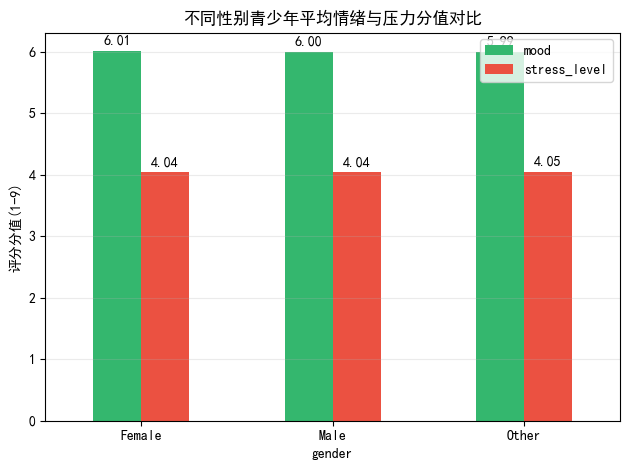

In [15]:
plt.figure(figsize=(8,5))
bar = gender_metric.plot(kind="bar", color=["#34b76e","#eb5141"])
for container in bar.containers:
    bar.bar_label(container, fmt="%.2f", padding=3)
plt.title("不同性别青少年平均情绪与压力分值对比")
plt.ylabel("评分分值(1-9)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [16]:
age_count = df.groupby("age_group").size()
age_metric = df.groupby("age_group")[["mood", "stress_level", "sleep_hours", "screen_time_hours"]].mean().round(2)
print("\n年龄段样本数量：\n", age_count)
print("\n不同年龄段各项指标均值：\n", age_metric)


年龄段样本数量：
 age_group
Young Teens (14-15)    14545
Older Teens (16-17)    15441
dtype: int64

不同年龄段各项指标均值：
                      mood  stress_level  sleep_hours  screen_time_hours
age_group                                                              
Young Teens (14-15)  5.99          4.05         6.49               6.98
Older Teens (16-17)  6.02          4.04         6.49               6.98


In [17]:
country_count = df.groupby("country").size()
country_metric = df.groupby("country")[["social_interaction_rating", "support_feeling"]].mean().round(2)
print("\n各国样本数量：\n", country_count)
print("\n各国社交评分、外界支持平均分：\n", country_metric)


各国样本数量：
 country
Australia    3838
Brazil       3298
Canada       4049
Germany      3687
India        3600
Japan        3296
UK           3689
USA          4529
dtype: int64

各国社交评分、外界支持平均分：
            social_interaction_rating  support_feeling
country                                              
Australia                       6.04             6.53
Brazil                          6.01             6.52
Canada                          6.00             6.47
Germany                         6.06             6.52
India                           6.02             6.46
Japan                           6.05             6.51
UK                              5.99             6.52
USA                             5.95             6.49


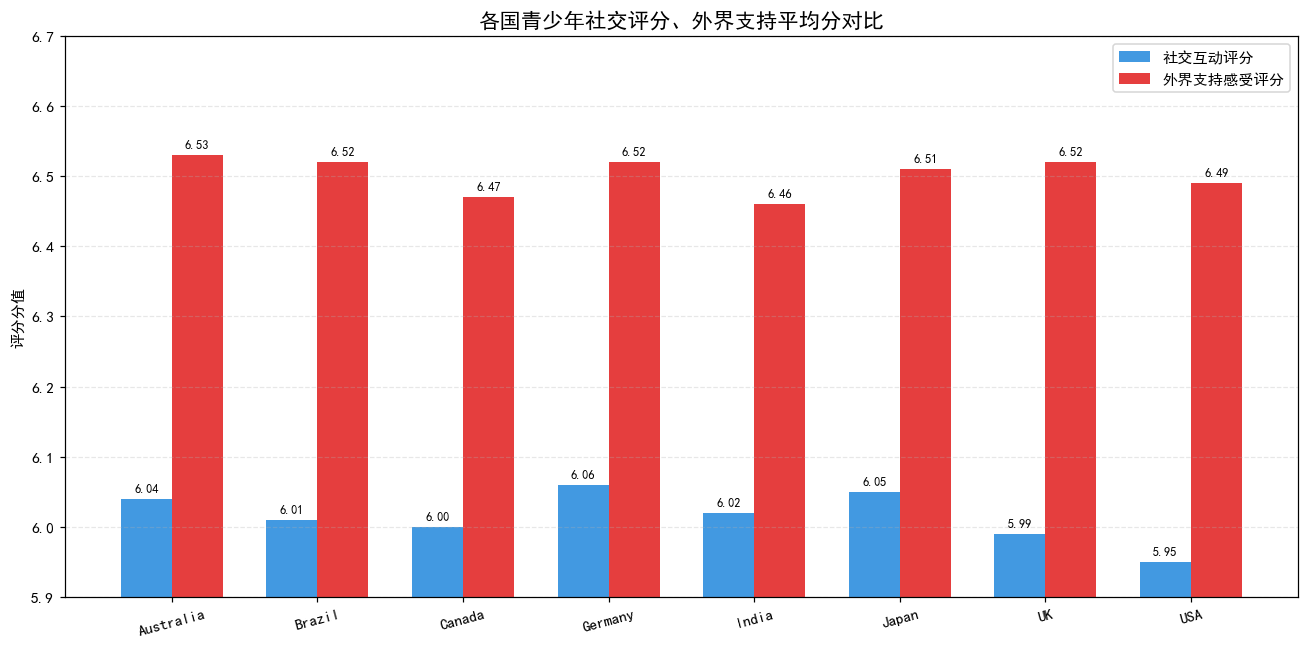

In [18]:
data = {
    "country": ["Australia", "Brazil", "Canada", "Germany", "India", "Japan", "UK", "USA"],
    "social_interaction_rating": [6.04, 6.01, 6.00, 6.06, 6.02, 6.05, 5.99, 5.95],
    "support_feeling": [6.53, 6.52, 6.47, 6.52, 6.46, 6.51, 6.52, 6.49]
}
df = pd.DataFrame(data)
plt.rcParams["axes.unicode_minus"] = False
plt.figure(figsize=(12,6), dpi=110)
x = np.arange(len(df["country"]))
bar_width = 0.35
bar_social = plt.bar(x - bar_width/2, df["social_interaction_rating"], width=bar_width,
                     color='#4299e1', label='社交互动评分')
bar_support = plt.bar(x + bar_width/2, df["support_feeling"], width=bar_width,
                      color='#e53e3e', label='外界支持感受评分')
def label_value(bars):
    for bar in bars:
        val = bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.2f}", ha='center', fontsize=8)
label_value(bar_social)
label_value(bar_support)
plt.title('各国青少年社交评分、外界支持平均分对比', fontsize=14)
plt.xticks(x, df["country"], rotation=15)
plt.ylabel('评分分值')
plt.ylim(5.9, 6.7)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

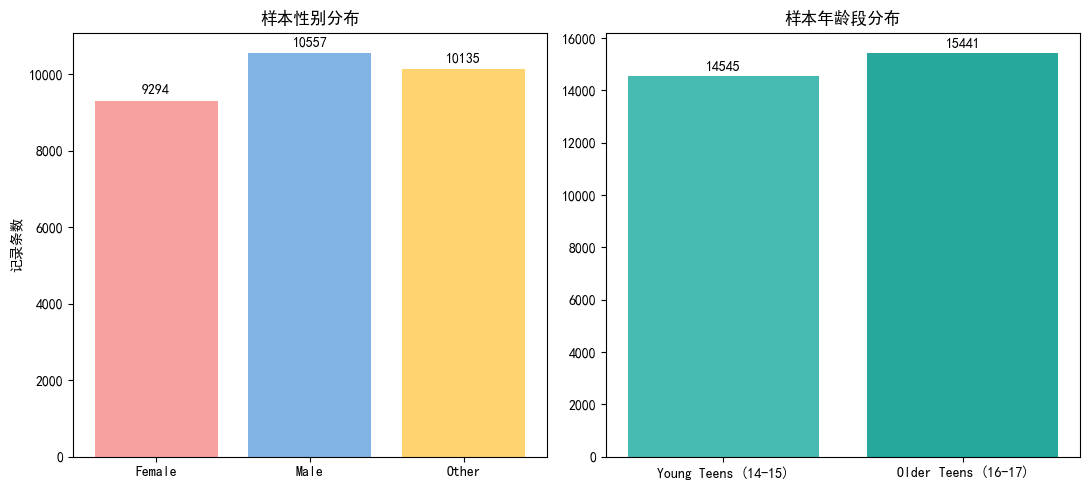

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
bars1 = ax1.bar(gender_count.index, gender_count.values, color=["#f8a1a1","#81b4e3","#ffd370"])
ax1.set_title("样本性别分布")
ax1.set_ylabel("记录条数")
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, height+120, f"{int(height)}",ha="center",va="bottom")
bars2 = ax2.bar(age_count.index, age_count.values, color=["#46b9b0","#27a89c"])
ax2.set_title("样本年龄段分布")
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, height+120, f"{int(height)}",ha="center",va="bottom")
ax1.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [20]:
ai_group = df.groupby("used_ai_today")[["mood", "stress_level", "sleep_hours", "screen_time_hours"]].mean().round(2)
print("使用AI与未使用AI指标对比：\n", ai_group)

使用AI与未使用AI指标对比：
                mood  stress_level  sleep_hours  screen_time_hours
used_ai_today                                                    
已使用AI          6.01          4.04         6.49               6.99
未使用AI          5.99          4.05         6.49               6.97


In [21]:
ai_tool_cnt = df["ai_tool"].value_counts()
print("\n各AI工具使用频次统计：\n", ai_tool_cnt)


各AI工具使用频次统计：
 ai_tool
未使用AI        12002
Gemini        3073
EduChat       3041
ChatGPT       3005
Notion AI     2996
Phind         2940
Grammarly     2929
Name: count, dtype: int64


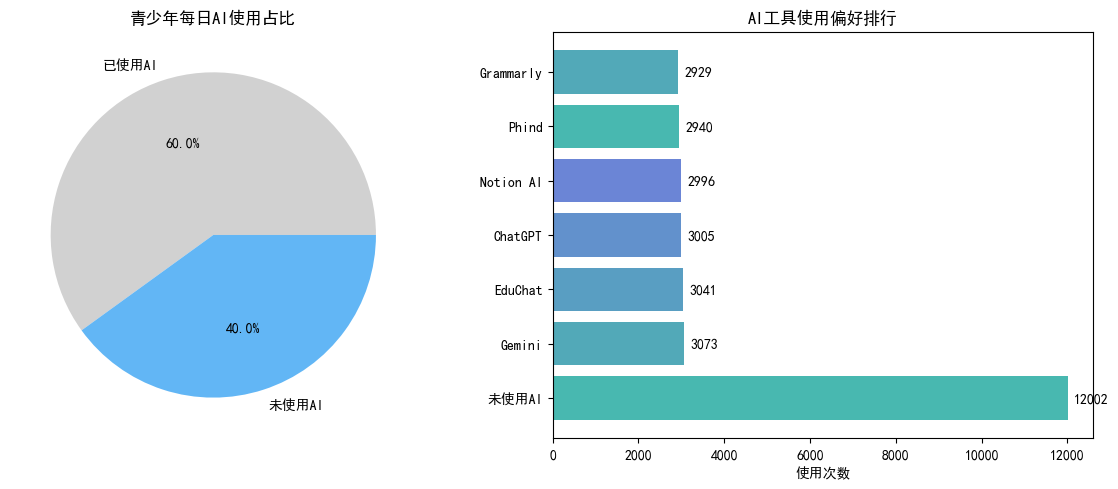

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
df["used_ai_today"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax1, colors=["#d1d1d1","#62b6f5"])
ax1.set_title("青少年每日AI使用占比")
ax1.set_ylabel("")
ai_tool_cnt = df["ai_tool"].value_counts()
colors = ["#48b8b0","#52a9b8","#599ec2","#6291cc","#6b85d6"]
bars = ax2.barh(ai_tool_cnt.index, ai_tool_cnt.values, color=colors)
ax2.set_title("AI工具使用偏好排行")
ax2.set_xlabel("使用次数")
for bar in bars:
    w = bar.get_width()
    ax2.text(w+150, bar.get_y()+bar.get_height()/2, f"{int(w)}", va="center")
plt.tight_layout()
plt.show()

In [23]:
age_sleep_screen = df.groupby("age_group")[["sleep_hours", "screen_time_hours"]].mean().round(2)
print("\n不同年龄段平均作息时长：\n", age_sleep_screen)


不同年龄段平均作息时长：
                      sleep_hours  screen_time_hours
age_group                                          
Young Teens (14-15)         6.49               6.98
Older Teens (16-17)         6.49               6.98


<Figure size 900x500 with 0 Axes>

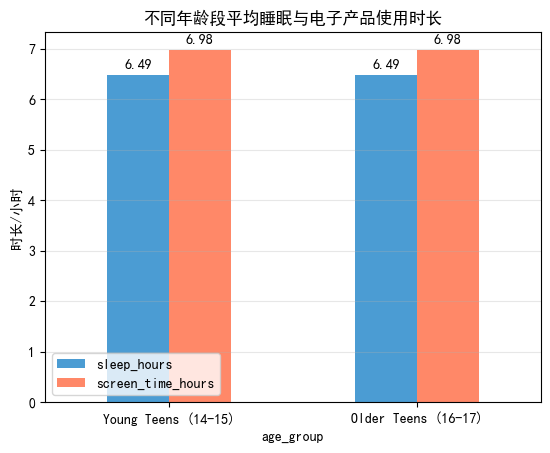

In [24]:
plt.figure(figsize=(9,5))
bar_obj = age_sleep_screen.plot(kind="bar", color=["#4b9cd3","#ff8868"])
plt.title("不同年龄段平均睡眠与电子产品使用时长")
plt.ylabel("时长/小时")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
for bar_group in bar_obj.containers:
    plt.bar_label(bar_group, fmt="%.2f", padding=3)
plt.show()

In [25]:
exercise_cnt = df["exercised_today"].value_counts()
meditate_cnt = df["meditated_today"].value_counts()
journal_cnt = df["journaled_today"].value_counts()
exercise_rate = df["exercised_today"].value_counts(normalize=True).round(3)*100
meditate_rate = df["meditated_today"].value_counts(normalize=True).round(3)*100
journal_rate = df["journaled_today"].value_counts(normalize=True).round(3)*100
print("====运动完成情况====")
print("数量：")
print(exercise_cnt)
print("\n占比(%)：")
print(exercise_rate)
print("\n====冥想完成情况====")
print("数量：")
print(meditate_cnt)
print("\n占比(%)：")
print(meditate_rate)
print("\n====写日记完成情况====")
print("数量：")
print(journal_cnt)
print("\n占比(%)：")
print(journal_rate)

====运动完成情况====
数量：
exercised_today
未运动    17996
已运动    11990
Name: count, dtype: int64

占比(%)：
exercised_today
未运动    60.0
已运动    40.0
Name: proportion, dtype: float64

====冥想完成情况====
数量：
meditated_today
未冥想    21090
已冥想     8896
Name: count, dtype: int64

占比(%)：
meditated_today
未冥想    70.3
已冥想    29.7
Name: proportion, dtype: float64

====写日记完成情况====
数量：
journaled_today
未写日记    15023
已写日记    14963
Name: count, dtype: int64

占比(%)：
journaled_today
未写日记    50.1
已写日记    49.9
Name: proportion, dtype: float64


In [26]:
exe_compare = df.groupby("exercised_today")[["mood","stress_level"]].mean().round(2)
med_compare = df.groupby("meditated_today")[["mood","stress_level"]].mean().round(2)
jou_compare = df.groupby("journaled_today")[["mood","stress_level"]].mean().round(2)
print("运动完成与否情绪压力对比：\n",exe_compare)
print("\n冥想完成与否情绪压力对比：\n",med_compare)
print("\n写日记完成与否情绪压力对比：\n",jou_compare)

运动完成与否情绪压力对比：
                  mood  stress_level
exercised_today                    
已运动              5.99          4.06
未运动              6.01          4.03

冥想完成与否情绪压力对比：
                  mood  stress_level
meditated_today                    
已冥想              5.99          4.05
未冥想              6.01          4.04

写日记完成与否情绪压力对比：
                  mood  stress_level
journaled_today                    
已写日记              6.0          4.04
未写日记              6.0          4.05


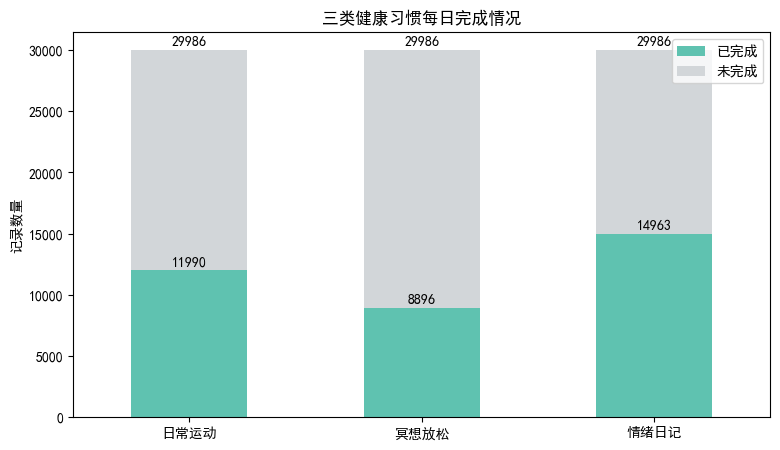

In [27]:
habit_df = pd.DataFrame({
    "已完成":[exercise_cnt["已运动"],meditate_cnt["已冥想"],journal_cnt["已写日记"]],
    "未完成":[exercise_cnt["未运动"],meditate_cnt["未冥想"],journal_cnt["未写日记"]]
},index=["日常运动","冥想放松","情绪日记"])
ax=habit_df.plot(kind="bar",stacked=True,figsize=(9,5),color=["#5fc2b0","#d2d6d9"])
plt.title("三类健康习惯每日完成情况")
plt.ylabel("记录数量")
plt.xticks(rotation=0)
for block in ax.containers:
    ax.bar_label(block,fmt="%d",padding=2)
plt.legend()
plt.show()

In [28]:
social_mid = df["social_interaction_rating"].median()
support_mid = df["support_feeling"].median()
df["social_level"] = np.where(df["social_interaction_rating"]>=social_mid, "高社交体验", "低社交体验")
df["support_level"] = np.where(df["support_feeling"]>=support_mid, "高外界支持", "低外界支持")
social_result = df.groupby("social_level")[["mood","stress_level"]].mean().round(2)
support_result = df.groupby("support_level")[["mood","stress_level"]].mean().round(2)
print("社交体验高低分组情绪压力对比：\n",social_result)
print("\n外界支持高低分组情绪压力对比：\n",support_result)

社交体验高低分组情绪压力对比：
               mood  stress_level
social_level                    
低社交体验          6.0          4.04
高社交体验          6.0          4.04

外界支持高低分组情绪压力对比：
                mood  stress_level
support_level                    
低外界支持           6.0          4.05
高外界支持           6.0          4.04


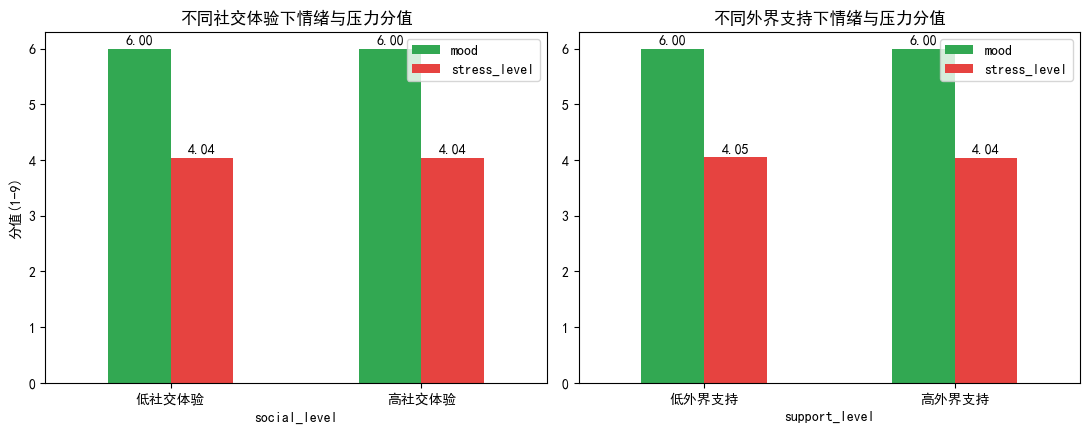

In [29]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(11,5))
p1 = social_result.plot(kind="bar",ax=ax1,color=["#32a852","#e64340"])
ax1.set_title("不同社交体验下情绪与压力分值")
ax1.set_ylabel("分值(1-9)")
for bar_set in p1.containers:
    ax1.bar_label(bar_set,fmt="%.2f",padding=2)
p2 = support_result.plot(kind="bar",ax=ax2,color=["#32a852","#e64340"])
ax2.set_title("不同外界支持下情绪与压力分值")
for bar_set in p2.containers:
    ax2.bar_label(bar_set,fmt="%.2f",padding=2)
plt.tight_layout()
ax1.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='x', rotation=0)
plt.show()

In [30]:
daily_trend = df.groupby("date")[["mood","stress_level","social_interaction_rating"]].mean().round(2)
print("30天每日各项指标均值（前10行）：\n",daily_trend.head(10))

30天每日各项指标均值（前10行）：
             mood  stress_level  social_interaction_rating
date                                                     
2025-01-01  5.94          4.12                       5.99
2025-01-02  6.01          4.02                       5.98
2025-01-03  5.98          4.07                       5.97
2025-01-04  6.03          4.03                       5.97
2025-01-05  6.02          4.02                       5.96
2025-01-06  5.99          4.04                       6.15
2025-01-07  6.00          4.04                       6.06
2025-01-08  5.93          4.09                       6.02
2025-01-09  5.98          4.07                       5.97
2025-01-10  6.12          3.92                       6.02


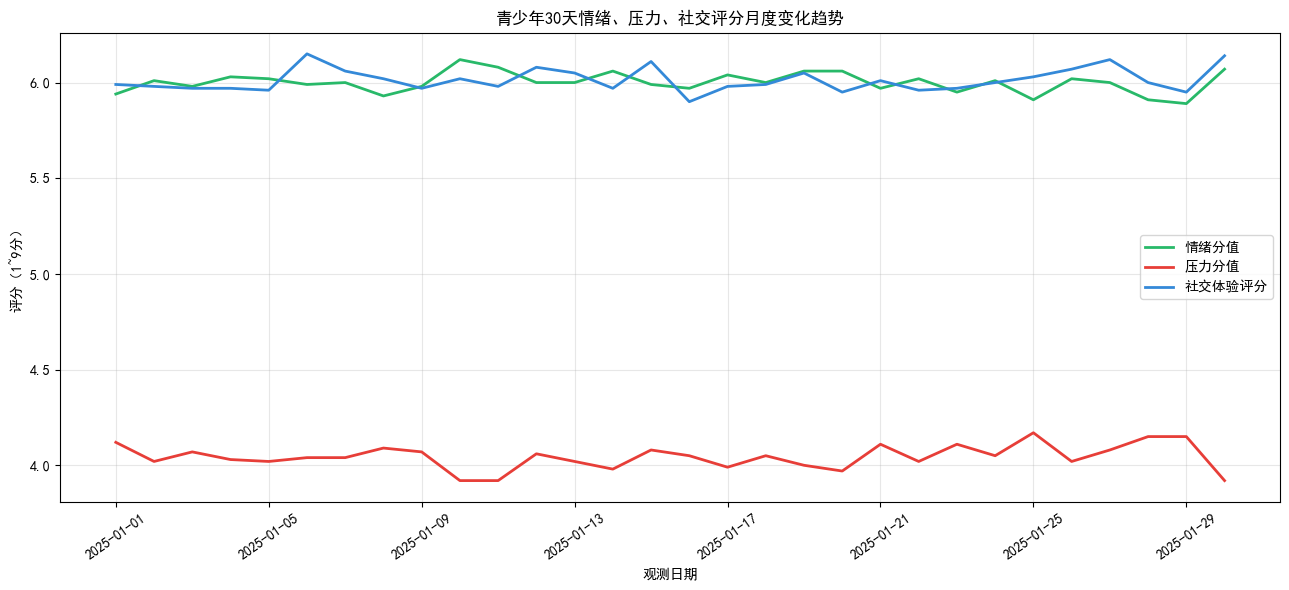

In [31]:
plt.figure(figsize=(13,6))
sns.lineplot(data=daily_trend["mood"],label="情绪分值",color="#28b969",linewidth=2)
sns.lineplot(data=daily_trend["stress_level"],label="压力分值",color="#e73e38",linewidth=2)
sns.lineplot(data=daily_trend["social_interaction_rating"],label="社交体验评分",color="#3489d8",linewidth=2)
plt.title("青少年30天情绪、压力、社交评分月度变化趋势")
plt.xlabel("观测日期")
plt.ylabel("评分（1~9分）")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [32]:
corr_cols = [
    "mood",                  
    "stress_level",          
    "sleep_hours",            
    "screen_time_hours",     
    "social_interaction_rating",
    "support_feeling"        
]
corr_df = df[corr_cols]

In [33]:
corr_matrix = np.corrcoef(corr_df.T)
print("========皮尔逊相关系数矩阵========")
print(np.round(corr_matrix, 3))

========皮尔逊相关系数矩阵========
[[ 1.    -0.926  0.005 -0.011 -0.004  0.002]
 [-0.926  1.    -0.006  0.01   0.003 -0.003]
 [ 0.005 -0.006  1.    -0.009  0.001  0.005]
 [-0.011  0.01  -0.009  1.    -0.003  0.009]
 [-0.004  0.003  0.001 -0.003  1.     0.006]
 [ 0.002 -0.003  0.005  0.009  0.006  1.   ]]


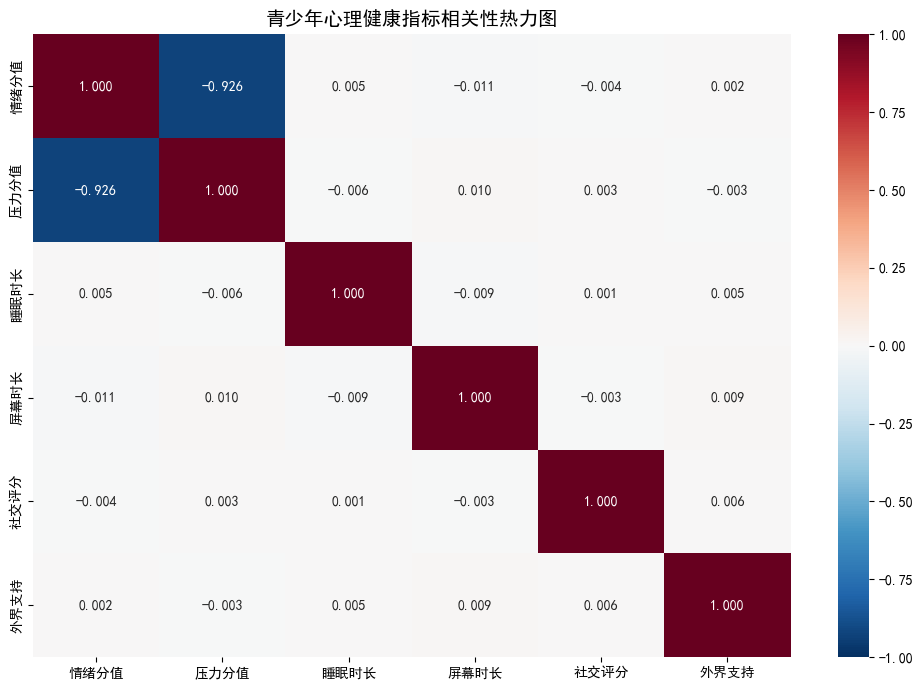

In [34]:
plt.figure(figsize=(10,7))
labels_cn = ["情绪分值","压力分值","睡眠时长","屏幕时长","社交评分","外界支持"]
sns.heatmap(
    corr_matrix,
    annot=True,     
    fmt=".3f",      
    cmap="RdBu_r",  
    vmin=-1, vmax=1,
    xticklabels=labels_cn,
    yticklabels=labels_cn
)
plt.title("青少年心理健康指标相关性热力图",fontsize=14)
plt.tight_layout()
plt.show()

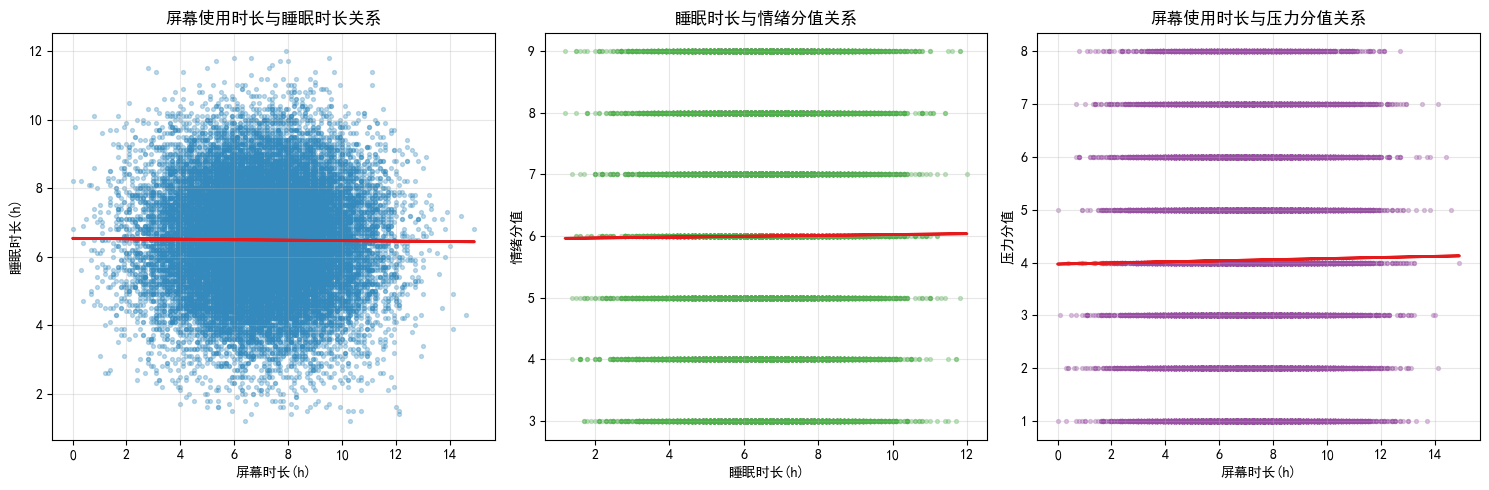

In [35]:
ig, axes = plt.subplots(1,3,figsize=(15,5))
x1 = df["screen_time_hours"]
y1 = df["sleep_hours"]
axes[0].scatter(x1,y1,alpha=0.3,color="#348abd",s=8)
z1 = np.polyfit(x1,y1,1)
p1 = np.poly1d(z1)
axes[0].plot(x1,p1(x1),color="#e41a1c",lw=2)
axes[0].set_title("屏幕使用时长与睡眠时长关系")
axes[0].set_xlabel("屏幕时长(h)")
axes[0].set_ylabel("睡眠时长(h)")
axes[0].grid(alpha=0.3)
x2 = df["sleep_hours"]
y2 = df["mood"]
axes[1].scatter(x2,y2,alpha=0.3,color="#4daf4a",s=8)
z2 = np.polyfit(x2,y2,1)
p2 = np.poly1d(z2)
axes[1].plot(x2,p2(x2),color="#e41a1c",lw=2)
axes[1].set_title("睡眠时长与情绪分值关系")
axes[1].set_xlabel("睡眠时长(h)")
axes[1].set_ylabel("情绪分值")
axes[1].grid(alpha=0.3)
x3 = df["screen_time_hours"]
y3 = df["stress_level"]
axes[2].scatter(x3,y3,alpha=0.3,color="#984ea3",s=8)
z3 = np.polyfit(x3,y3,1)
p3 = np.poly1d(z3)
axes[2].plot(x3,p3(x3),color="#e41a1c",lw=2)
axes[2].set_title("屏幕使用时长与压力分值关系")
axes[2].set_xlabel("屏幕时长(h)")
axes[2].set_ylabel("压力分值")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

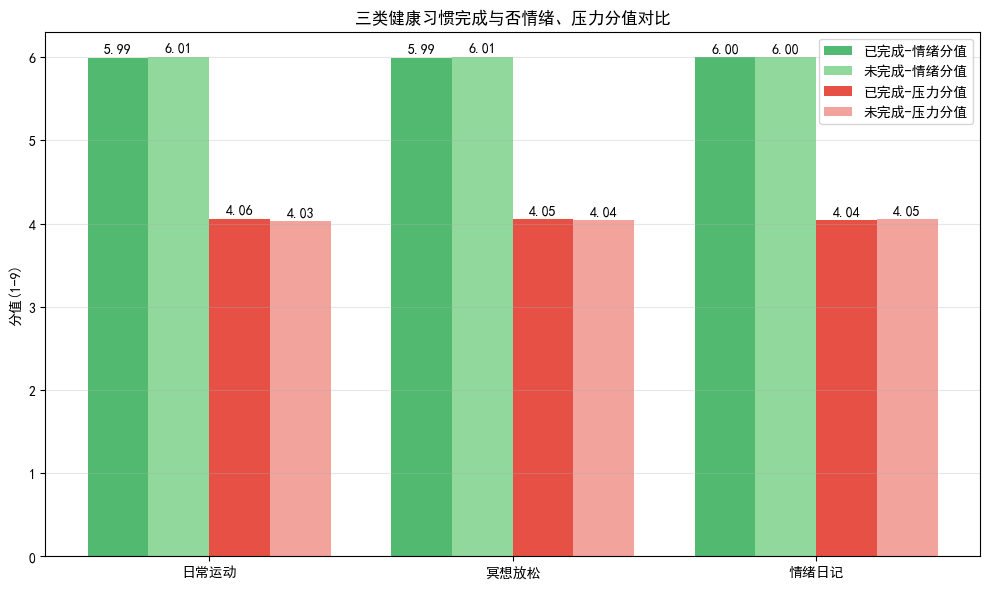

In [36]:
exe_data = df.groupby("exercised_today")[["mood","stress_level"]].mean().round(2)
med_data = df.groupby("meditated_today")[["mood","stress_level"]].mean().round(2)
jou_data = df.groupby("journaled_today")[["mood","stress_level"]].mean().round(2)
habit_name = ["日常运动","冥想放松","情绪日记"]
done_mood = [exe_data.loc["已运动","mood"],med_data.loc["已冥想","mood"],jou_data.loc["已写日记","mood"]]
undone_mood = [exe_data.loc["未运动","mood"],med_data.loc["未冥想","mood"],jou_data.loc["未写日记","mood"]]
done_stress = [exe_data.loc["已运动","stress_level"],med_data.loc["已冥想","stress_level"],jou_data.loc["已写日记","stress_level"]]
undone_stress = [exe_data.loc["未运动","stress_level"],med_data.loc["未冥想","stress_level"],jou_data.loc["未写日记","stress_level"]]
x = np.arange(len(habit_name))
width = 0.2
fig,ax = plt.subplots(figsize=(10,6))
bar1 = ax.bar(x-width*1.5,done_mood,width,label="已完成-情绪分值",color="#52b970")
bar2 = ax.bar(x-width/2,undone_mood,width,label="未完成-情绪分值",color="#90d89c")
bar3 = ax.bar(x+width/2,done_stress,width,label="已完成-压力分值",color="#e65045")
bar4 = ax.bar(x+width*1.5,undone_stress,width,label="未完成-压力分值",color="#f2a39c")
for bars in [bar1,bar2,bar3,bar4]:
    ax.bar_label(bars,fmt="%.2f",padding=2)
ax.set_title("三类健康习惯完成与否情绪、压力分值对比")
ax.set_xticks(x)
ax.set_xticklabels(habit_name)
ax.set_ylabel("分值(1-9)")
ax.legend()
ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()

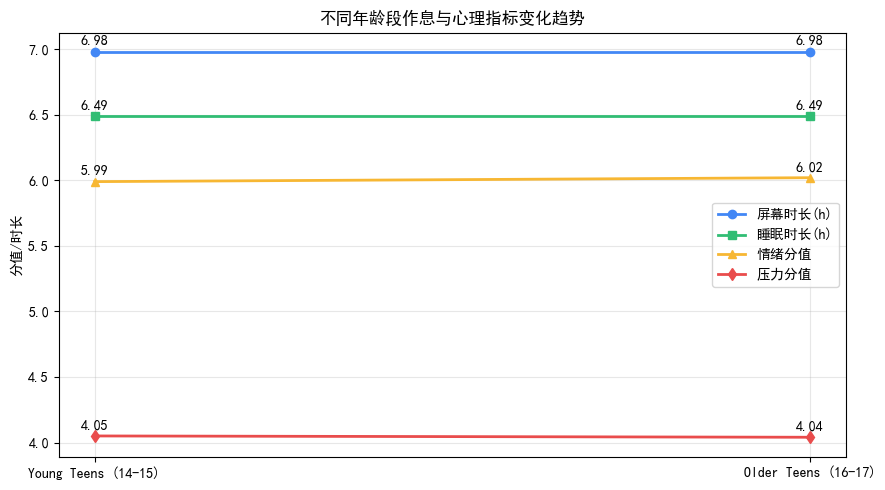

In [37]:
age_info = df.groupby("age_group")[["screen_time_hours","sleep_hours","mood","stress_level"]].mean().round(2)
fig,ax = plt.subplots(figsize=(9,5))
ax.plot(age_info.index,age_info["screen_time_hours"],marker="o",linewidth=2,label="屏幕时长(h)",color="#4287f5")
ax.plot(age_info.index,age_info["sleep_hours"],marker="s",linewidth=2,label="睡眠时长(h)",color="#31bd74")
ax.plot(age_info.index,age_info["mood"],marker="^",linewidth=2,label="情绪分值",color="#f7b733")
ax.plot(age_info.index,age_info["stress_level"],marker="d",linewidth=2,label="压力分值",color="#e94c4c")
for col in age_info.columns:
    for idx,val in enumerate(age_info[col]):
        ax.text(idx,val+0.05,f"{val}",ha="center")
ax.set_title("不同年龄段作息与心理指标变化趋势")
ax.set_ylabel("分值/时长")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

屏幕时长分段指标变化：
                    sleep_hours  mood  stress_level
screen_time_hours                                 
(0, 1]                    6.52  6.30          3.55
(1, 2]                    6.50  6.01          4.07
(2, 3]                    6.45  6.17          3.88
(3, 4]                    6.52  6.04          4.01
(4, 5]                    6.50  5.99          4.04
(5, 6]                    6.50  6.03          4.01
(6, 7]                    6.50  5.98          4.07
(7, 8]                    6.49  5.99          4.05
(8, 9]                    6.50  6.00          4.04
(9, 10]                   6.48  5.97          4.07
(10, 11]                  6.36  5.97          4.08
(11, 12]                  6.48  5.95          4.12
(12, 13]                  6.33  6.24          3.88
(13, 14]                  6.79  5.84          4.05
(14, 15]                  5.42  5.20          4.80


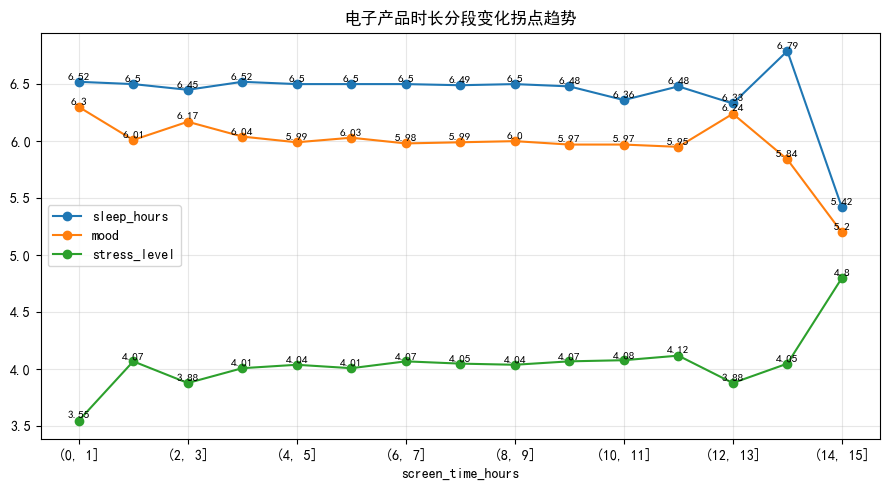

In [45]:
screen_bin = pd.cut(df["screen_time_hours"], bins=range(0,16,1))
turn_point = df.groupby(screen_bin)[["sleep_hours","mood","stress_level"]].mean().round(2)
print("屏幕时长分段指标变化：\n",turn_point)
ax = turn_point.plot(marker="o",figsize=(9,5))
plt.title("电子产品时长分段变化拐点趋势")
plt.grid(alpha=0.3)
for line in ax.lines:
    x_list = line.get_xdata()
    y_list = line.get_ydata()
    for x,y in zip(x_list,y_list):
        ax.text(x,y+0.02,f"{y}",ha="center",fontsize=8)
plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import ttest_ind
exe_done_mood = df[df["exercised_today"]=="已运动"]["mood"]
exe_undone_mood = df[df["exercised_today"]=="未运动"]["mood"]
exe_done_stress = df[df["exercised_today"]=="已运动"]["stress_level"]
exe_undone_stress = df[df["exercised_today"]=="未运动"]["stress_level"]
t1,p1 = ttest_ind(exe_done_mood,exe_undone_mood)
t2,p2 = ttest_ind(exe_done_stress,exe_undone_stress)
print("==========运动习惯组对比==========")
print(f"运动/不运动 情绪差异P值：{round(p1,4)}")
print(f"运动/不运动 压力差异P值：{round(p2,4)}")
print("情绪差异：✅显著" if p1<0.05 else "情绪差异：❌不显著")
print("压力差异：✅显著" if p2<0.05 else "压力差异：❌不显著")
med_done_mood = df[df["meditated_today"]=="已冥想"]["mood"]
med_undone_mood = df[df["meditated_today"]=="未冥想"]["mood"]
med_done_stress = df[df["meditated_today"]=="已冥想"]["stress_level"]
med_undone_stress = df[df["meditated_today"]=="未冥想"]["stress_level"]
t3,p3 = ttest_ind(med_done_mood,med_undone_mood)
t4,p4 = ttest_ind(med_done_stress,med_undone_stress)
print("\n==========冥想习惯组对比==========")
print(f"冥想/不冥想 情绪差异P值：{round(p3,4)}")
print(f"冥想/不冥想 压力差异P值：{round(p4,4)}")
print("情绪差异：✅显著" if p3<0.05 else "情绪差异：❌不显著")
print("压力差异：✅显著" if p4<0.05 else "压力差异：❌不显著")
jour_done_mood = df[df["journaled_today"]=="已写日记"]["mood"]
jour_undone_mood = df[df["journaled_today"]=="未写日记"]["mood"]
jour_done_stress = df[df["journaled_today"]=="已写日记"]["stress_level"]
jour_undone_stress = df[df["journaled_today"]=="未写日记"]["stress_level"]
t5,p5 = ttest_ind(jour_done_mood,jour_undone_mood)
t6,p6 = ttest_ind(jour_done_stress,jour_undone_stress)
print("\n==========写日记习惯组对比==========")
print(f"写日记/不写日记 情绪差异P值：{round(p5,4)}")
print(f"写日记/不写日记 压力差异P值：{round(p6,4)}")
print("情绪差异：✅显著" if p5<0.05 else "情绪差异：❌不显著")
print("压力差异：✅显著" if p6<0.05 else "压力差异：❌不显著")

==========运动习惯组对比==========
运动/不运动 情绪差异P值：0.3987
运动/不运动 压力差异P值：0.3112
情绪差异：❌不显著
压力差异：❌不显著

==========冥想习惯组对比==========
冥想/不冥想 情绪差异P值：0.4535
冥想/不冥想 压力差异P值：0.8422
情绪差异：❌不显著
压力差异：❌不显著

==========写日记习惯组对比==========
写日记/不写日记 情绪差异P值：0.8391
写日记/不写日记 压力差异P值：0.8553
情绪差异：❌不显著
压力差异：❌不显著


In [47]:
from scipy.stats import pearsonr
def partial_corr(x,y,control):
    r_xy,_=pearsonr(x,y)
    r_xc,_=pearsonr(x,control)
    r_yc,_=pearsonr(y,control)
    res=(r_xy-r_xc*r_yc)/np.sqrt((1-r_xc**2)*(1-r_yc**2))
    return round(res,3)
raw_corr,_=pearsonr(df["screen_time_hours"],df["mood"])
part_corr=partial_corr(df["screen_time_hours"],df["mood"],df["sleep_hours"])
print(f"屏幕时长—情绪原始相关系数：{raw_corr:.3f}")
print(f"剔除睡眠影响后相关系数：{part_corr}")

屏幕时长—情绪原始相关系数：-0.011
剔除睡眠影响后相关系数：-0.01


====三类青少年群体特征画像====
            screen_time_hours  sleep_hours  mood  stress_level
group_type                                                    
0                        7.04         6.47  4.12          5.98
1                        8.57         6.49  7.56          2.44
2                        5.20         6.51  7.46          2.54


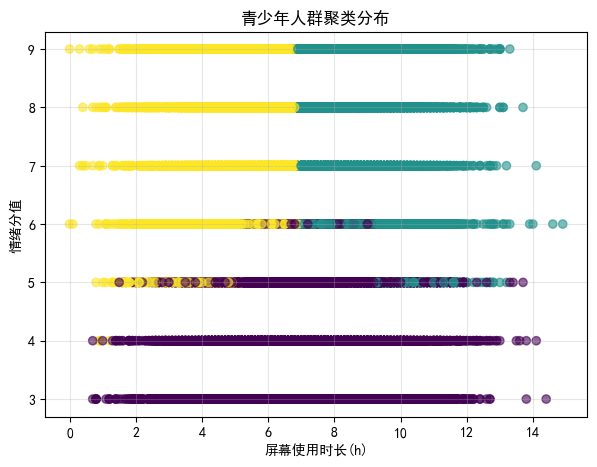

In [48]:
from sklearn.cluster import KMeans
features = ["screen_time_hours","sleep_hours","mood","stress_level"]
data_cluster = df[features]
kmeans = KMeans(n_clusters=3,random_state=10)
df["group_type"] = kmeans.fit_predict(data_cluster)
cluster_res = df.groupby("group_type")[features].mean().round(2)
print("====三类青少年群体特征画像====")
print(cluster_res)
plt.figure(figsize=(7,5))
plt.scatter(df["screen_time_hours"],df["mood"],c=df["group_type"],cmap="viridis",alpha=0.6)
plt.xlabel("屏幕使用时长(h)")
plt.ylabel("情绪分值")
plt.title("青少年人群聚类分布")
plt.grid(alpha=0.3)
plt.show()

===完成习惯数量与心理指标变化===
           mood  stress_level
habit_num                    
0          6.01          4.04
1          6.00          4.04
2          6.00          4.05
3          5.95          4.07


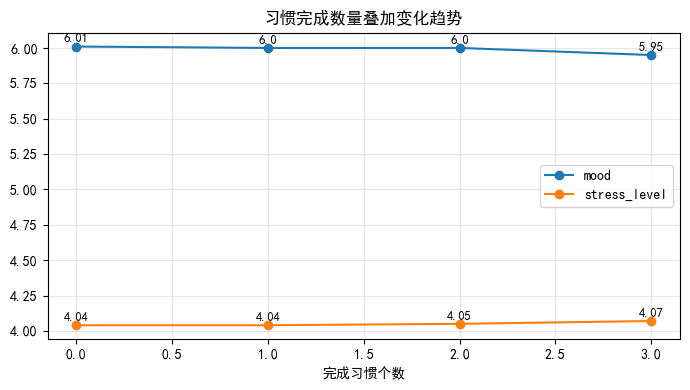

In [49]:
def count_habit(row):
    cnt = 0
    if row["exercised_today"]=="已运动":cnt+=1
    if row["meditated_today"]=="已冥想":cnt+=1
    if row["journaled_today"]=="已写日记":cnt+=1
    return cnt
df["habit_num"] = df.apply(count_habit,axis=1)
habit_effect = df.groupby("habit_num")[["mood","stress_level"]].mean().round(2)
print("===完成习惯数量与心理指标变化===")
print(habit_effect)
ax = habit_effect.plot(marker="o",figsize=(7,4))
plt.title("习惯完成数量叠加变化趋势")
plt.xlabel("完成习惯个数")
plt.grid(alpha=0.3)
for line in ax.lines:
    x_arr = line.get_xdata()
    y_arr = line.get_ydata()
    for x,y in zip(x_arr,y_arr):
        ax.text(x, y+0.03, f"{y}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

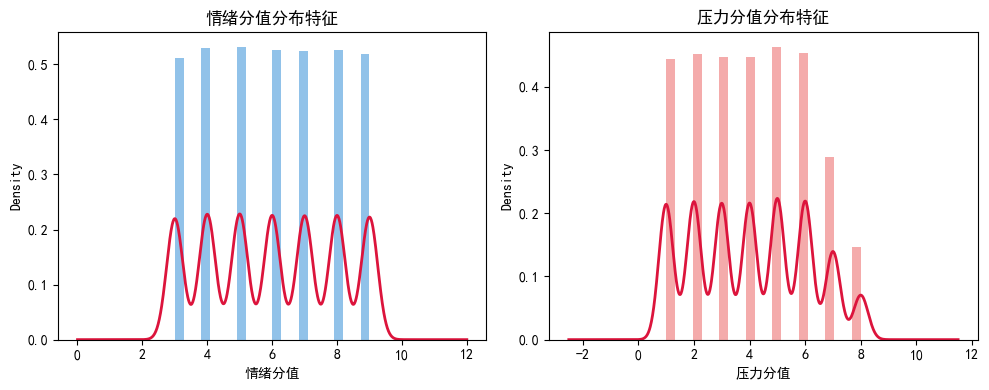

In [50]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
df["mood"].plot(kind="hist",density=True,bins=22,ax=ax1,color="#63a8e0",alpha=0.7)
df["mood"].plot.kde(ax=ax1,c="crimson",lw=2)
ax1.set_title("情绪分值分布特征")
ax1.set_xlabel("情绪分值")
df["stress_level"].plot(kind="hist",density=True,bins=22,ax=ax2,color="#f08888",alpha=0.7)
df["stress_level"].plot.kde(ax=ax2,c="crimson",lw=2)
ax2.set_title("压力分值分布特征")
ax2.set_xlabel("压力分值")
plt.tight_layout()
plt.show()

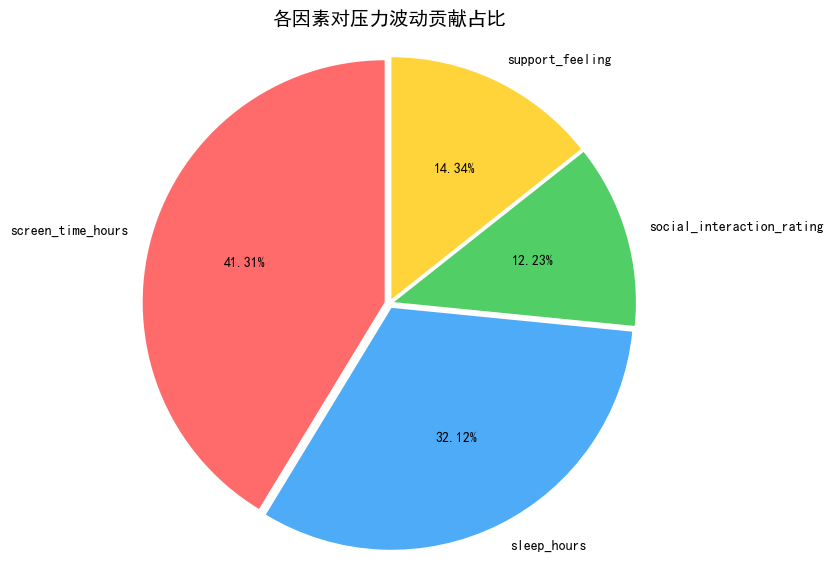

In [51]:
import statsmodels.api as sm
X=df[["screen_time_hours","sleep_hours","social_interaction_rating","support_feeling"]]
X=sm.add_constant(X)
Y=df["stress_level"]
model=sm.OLS(Y,X).fit()
coef=abs(model.params[1:])
rate=(coef/coef.sum()*100).round(2)
name_list = rate.index.tolist()
data_list = rate.values.tolist()
color_list = ['#ff6b6b','#4dabf7','#51cf66','#ffd43b']
plt.figure(figsize=(7,7))
plt.pie(data_list,labels=name_list,autopct='%.2f%%',colors=color_list,
        startangle=90,explode=[0.02]*4)
plt.title('各因素对压力波动贡献占比',fontsize=14)
plt.axis('equal')
plt.show()

Contribution proportion of each factor to stress fluctuation:
screen_time_hours : 41.31%
sleep_hours : 32.12%
social_interaction_rating : 12.23%
support_feeling : 14.34%


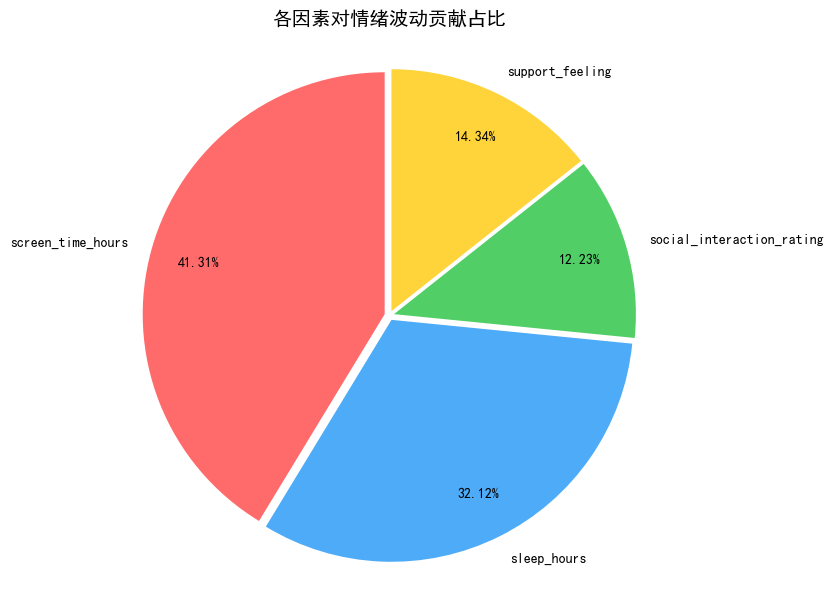

In [52]:
X=df[["screen_time_hours","sleep_hours","social_interaction_rating","support_feeling"]]
X=sm.add_constant(X)
Y=df["stress_level"]
model=sm.OLS(Y,X).fit()
coef=abs(model.params[1:])
rate=(coef/coef.sum()*100).round(2)
print("Contribution proportion of each factor to stress fluctuation:")
for name,value in zip(X.columns[1:],rate):
    print(f"{name} : {value}%")
labels = rate.index.tolist()
data = rate.values.tolist()
colors = ['#ff6b6b','#4dabf7','#51cf66','#ffd43b']
plt.figure(figsize=(7,7))
plt.pie(data,labels=labels,autopct='%.2f%%',colors=colors,
        startangle=90,explode=[0.02,0.02,0.02,0.02],pctdistance=0.8)
plt.title("各因素对情绪波动贡献占比",fontsize=14,pad=15)
plt.axis("equal")
plt.show()

In [60]:
Q1=df["sleep_hours"].quantile(0.25)
Q3=df["sleep_hours"].quantile(0.75)
IQR=Q3-Q1
sleep_low=df[df["sleep_hours"]<Q1-1.5*IQR]
print(f"睡眠极端偏少样本数量：{len(sleep_low)}")
print("极端睡眠人群均值特征：\n",sleep_low[["screen_time_hours","mood","stress_level"]].mean().round(2))
Q1_mood = df["mood"].quantile(0.25)
mood_low = df[df["mood"] <= Q1_mood]
print(f"\n情绪偏低样本数量：{len(mood_low)}")
print("低落人群均值特征：\n",mood_low[["screen_time_hours","sleep_hours","stress_level"]].mean().round(2))

睡眠极端偏少样本数量：124
极端睡眠人群均值特征：
 screen_time_hours    7.24
mood                 5.79
stress_level         4.18
dtype: float64

情绪偏低样本数量：8521
低落人群均值特征：
 screen_time_hours    7.02
sleep_hours          6.49
stress_level         6.48
dtype: float64


In [61]:
def mental_tag(row):
    if row["mood"]>=6.2 and row["stress_level"]<=4.1:
        return"优良组"
    elif row["mood"]<=5.9 and row["stress_level"]>=4.4:
        return"薄弱组"
    else:
        return"中等组"
df["mental_type"]=df.apply(mental_tag,axis=1)
res=df.groupby("mental_type")[["screen_time_hours","sleep_hours","social_interaction_rating","support_feeling"]].mean().round(2)
print("优劣心理人群行为溯源对比：\n",res)

优劣心理人群行为溯源对比：
              screen_time_hours  sleep_hours  social_interaction_rating  \
mental_type                                                              
中等组                       7.00         6.48                       6.00   
优良组                       6.95         6.50                       6.01   
薄弱组                       7.01         6.48                       6.02   

             support_feeling  
mental_type                   
中等组                     6.53  
优良组                     6.50  
薄弱组                     6.49  


In [62]:
df["screen_high"] = df["screen_time_hours"].apply(lambda x:"时长偏高" if x>6 else "时长偏低")
df["sleep_low"] = df["sleep_hours"].apply(lambda x:"睡眠不足" if x<7 else "睡眠充足")
couple = df.groupby(["screen_high","sleep_low"])[["mood","stress_level"]].mean().round(2)
print("            屏幕时长与睡眠耦合叠加效应统计表")
print(couple.to_string(col_space=[12,12],justify="right"))

            屏幕时长与睡眠耦合叠加效应统计表
                              mood  stress_level
screen_high sleep_low                           
时长偏低        睡眠不足              6.05          3.99
            睡眠充足              6.01          4.04
时长偏高        睡眠不足              5.98          4.07
            睡眠充足              6.00          4.04


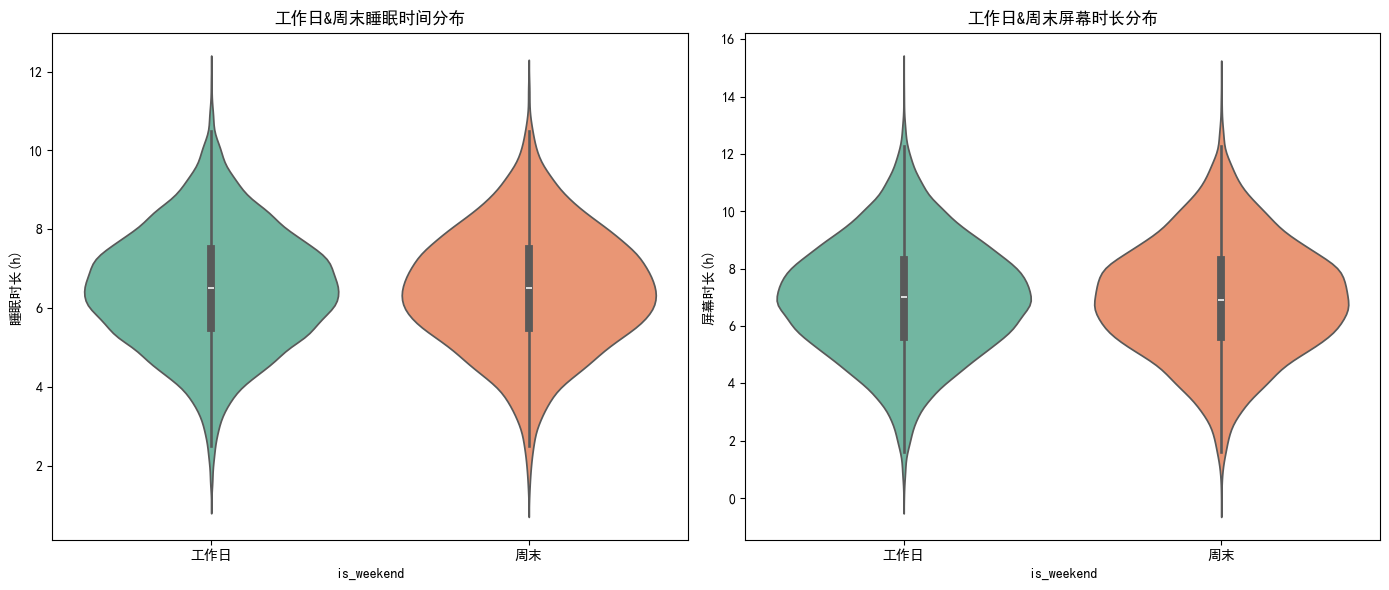

In [68]:
import seaborn as sns
df["weekday"] = df["date"].dt.weekday  
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.violinplot(x="is_weekend",
               y="sleep_hours",
               hue="is_weekend",
               data=df,
               palette="Set2",
               legend=False,
               ax=ax1)
ax1.set_xticks([0,1])
ax1.set_xticklabels(["工作日","周末"])
ax1.set_title("工作日&周末睡眠时间分布",fontsize=12)
ax1.set_ylabel("睡眠时长(h)")
sns.violinplot(x="is_weekend",
               y="screen_time_hours",
               hue="is_weekend",
               data=df,
               palette="Set2",
               legend=False,
               ax=ax2)
ax2.set_xticks([0,1])
ax2.set_xticklabels(["工作日","周末"])
ax2.set_title("工作日&周末屏幕时长分布",fontsize=12)
ax2.set_ylabel("屏幕时长(h)")
plt.tight_layout()
plt.show()

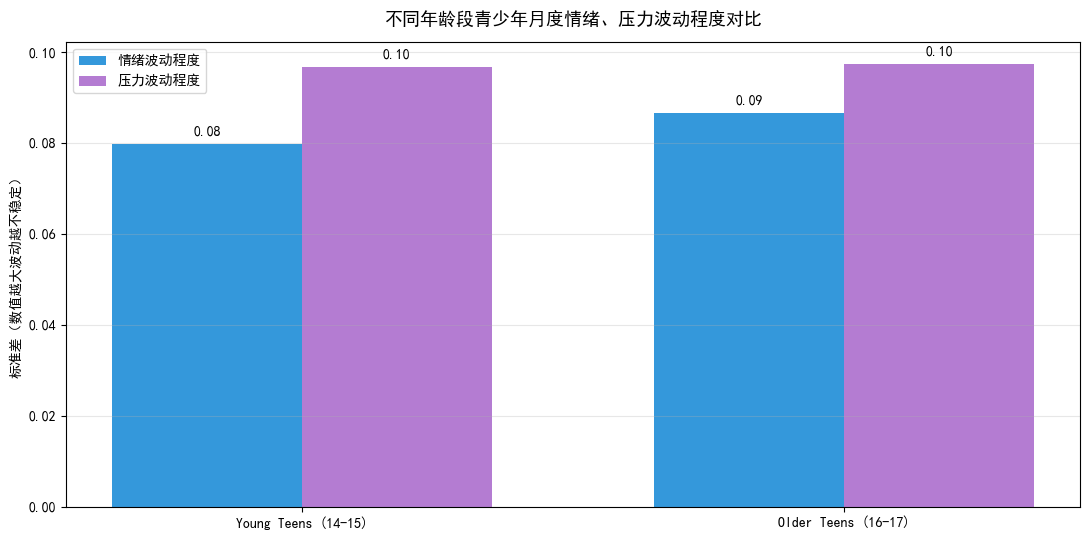

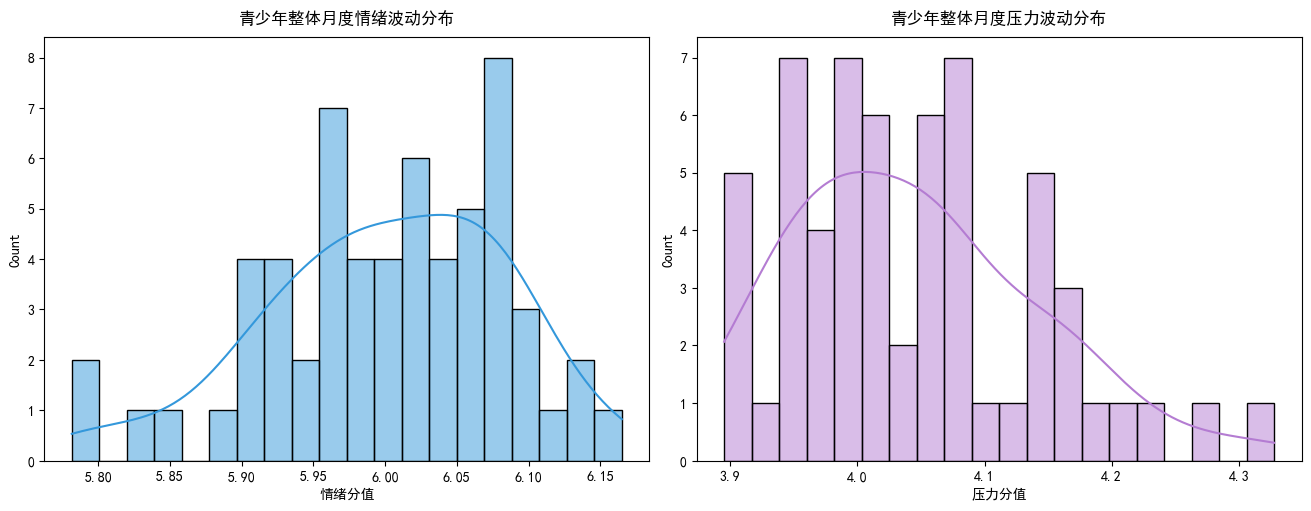

In [69]:
group_day = df.groupby(["age_group","date"])[["mood","stress_level"]].mean().reset_index()
age_fluct = group_day.groupby("age_group")[["mood","stress_level"]].std().reset_index()
age_fluct.columns = ["age_group","情绪波动标准差","压力波动标准差"]
plt.figure(figsize=(11,5.5))
x = np.arange(len(age_fluct["age_group"]))
width = 0.35
bar1 = plt.bar(x-width/2, age_fluct["情绪波动标准差"], width, 
               label="情绪波动程度",color="#3498db")
bar2 = plt.bar(x+width/2, age_fluct["压力波动标准差"], width, 
               label="压力波动程度",color="#b47cd2")
def add_text(bar_list):
    for bar in bar_list:
        h = bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2, h+0.0015,
                 f"{h:.2f}",ha="center",va="bottom",fontsize=10,weight="medium")
add_text(bar1)
add_text(bar2)
plt.xticks(x,age_fluct["age_group"],fontsize=10)
plt.title("不同年龄段青少年月度情绪、压力波动程度对比",fontsize=13,pad=12)
plt.ylabel("标准差（数值越大波动越不稳定）",fontsize=10)
plt.legend(fontsize=10)
plt.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.show()
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
sns.histplot(group_day["mood"],bins=20,kde=True,ax=ax1,color="#3498db")
ax1.set_title("青少年整体月度情绪波动分布",fontsize=12,pad=10)
ax1.set_xlabel("情绪分值",fontsize=10)

sns.histplot(group_day["stress_level"],bins=20,kde=True,ax=ax2,color="#b47cd2")
ax2.set_title("青少年整体月度压力波动分布",fontsize=12,pad=10)
ax2.set_xlabel("压力分值",fontsize=10)
plt.show()

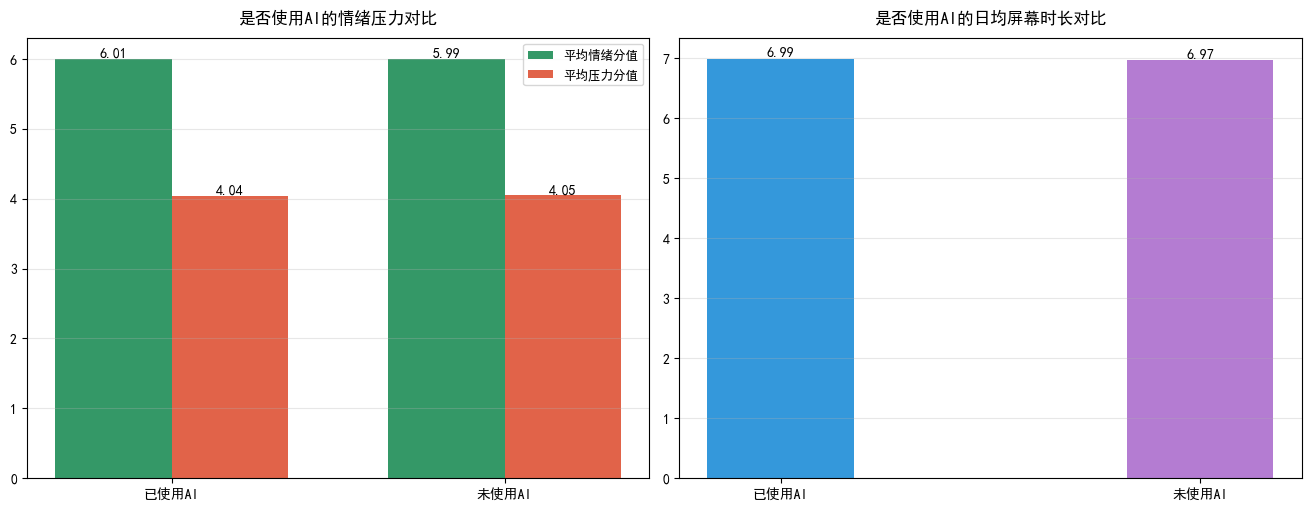

In [70]:
ai_data = df.groupby("used_ai_today")[["mood","stress_level","screen_time_hours"]].mean().reset_index()
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
x = np.arange(len(ai_data["used_ai_today"]))
width = 0.35
bar1 = ax1.bar(x-width/2, ai_data["mood"], width, color="#349867", label="平均情绪分值")
bar2 = ax1.bar(x+width/2, ai_data["stress_level"], width, color="#e16349", label="平均压力分值")
ax1.set_title("是否使用AI的情绪压力对比",fontsize=12,pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(ai_data["used_ai_today"]) 
ax1.legend(fontsize=9)
ax1.grid(axis="y",alpha=0.3)
bar3 = ax2.bar(x, ai_data["screen_time_hours"], width, color=["#3498db","#b47cd2"])
ax2.set_title("是否使用AI的日均屏幕时长对比",fontsize=12,pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(ai_data["used_ai_today"])
ax2.grid(axis="y",alpha=0.3)
def add_num(barlist):
    for bar in barlist:
        h = bar.get_height()
        ax = bar.axes
        ax.text(bar.get_x()+bar.get_width()/2, h+0.03, f"{h:.2f}",ha="center",fontsize=10)
add_num(bar1)
add_num(bar2)
add_num(bar3)

plt.show()